# Task 3: U.S. Dividend-Based Valuation, 1825–2025

The historical NYSE series is used through 1925 and the Shiller S&P Composite series from 1926 onward. The two series overlap in 1925, which provides the bridge for joining the price and dividend levels without creating an artificial change at the splice.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

from scipy.stats import shapiro, jarque_bera
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf

nyse = pd.read_csv("nyse_data.csv")
shiller = pd.read_excel("data7.xlsx", sheet_name="data")

## 1. Historical series

For the historical NYSE data, the one-year dividend is reconstructed from the previous price index and the low-dividend return:

$$
D_t=S_{t-1}R_t^D.
$$

The published annual table gives a low-dividend return of 4.26% for 1868; this value is used for the missing observation in the electronic series.

In [2]:
hist = nyse[(nyse["Year"] >= 1824) & (nyse["Year"] <= 1925)].copy()

hist["S"] = hist["Price-weighted Appreciation Index"]
hist["S_prev"] = hist["S"].shift(1)

hist["dividend_return"] = (
    hist["Total return with low dividends"]
    - hist["Price-weighted Capital Appreciation"]
)
hist.loc[hist["Year"] == 1868, "dividend_return"] = 0.0426

hist["D"] = hist["S_prev"] * hist["dividend_return"]

hist.loc[hist["Year"].between(1923, 1925),
         ["Year", "S", "D", "dividend_return"]]

,Year,S,D,dividend_return
109,1923,2.684709,0.165595,0.060364
110,1924,3.203862,0.172701,0.064327
111,1925,3.947692,0.189204,0.059055


## 2. Join the two series

The historical and Shiller series use different index scales. The 1925 overlap is used to align them.

The historical price index is multiplied by

$$
k_S=\frac{S_{1925}^{\mathrm{Shiller}}}
{S_{1925}^{\mathrm{NYSE}}},
$$

and the reconstructed historical dividends are multiplied by

$$
k_D=\frac{D_{1925}^{\mathrm{Shiller}}}
{D_{1925}^{\mathrm{NYSE}}}.
$$

Separate constants are used because the historical source reports a dividend return rather than a dividend level. This preserves all within-sample historical growth rates while making both price and dividend levels agree exactly at the 1925 bridge.

In [3]:
S_1925_shiller = shiller.loc[shiller["Year"] == 1925, "Index"].iloc[0]
D_1925_shiller = shiller.loc[shiller["Year"] == 1925, "Dividend"].iloc[0]

S_1925_hist = hist.loc[hist["Year"] == 1925, "S"].iloc[0]
D_1925_hist = hist.loc[hist["Year"] == 1925, "D"].iloc[0]

k_S = S_1925_shiller / S_1925_hist
k_D = D_1925_shiller / D_1925_hist

hist["S"] = hist["S"] * k_S
hist["D"] = hist["D"] * k_D

In [4]:
print("Price scaling factor:", round(k_S, 6))
print("Dividend scaling factor:", round(k_D, 6))
print()
print("1925 historical price after scaling:",
      round(hist.loc[hist["Year"] == 1925, "S"].iloc[0], 4))
print("1925 Shiller price:", round(S_1925_shiller, 4))
print("1925 historical dividend after scaling:",
      round(hist.loc[hist["Year"] == 1925, "D"].iloc[0], 4))
print("1925 Shiller dividend:", round(D_1925_shiller, 4))

Price scaling factor: 2.680047
Dividend scaling factor: 3.171173

1925 historical price after scaling: 10.58
1925 Shiller price: 10.58
1925 historical dividend after scaling: 0.6
1925 Shiller dividend: 0.6


In [5]:
hist_part = hist[(hist["Year"] >= 1825) & (hist["Year"] <= 1925)][
    ["Year", "S", "D"]
].copy()
hist_part["Source"] = "Historical NYSE"

modern_part = shiller[(shiller["Year"] >= 1926) & (shiller["Year"] <= 2025)][
    ["Year", "Index", "Dividend"]
].copy()
modern_part = modern_part.rename(columns={"Index": "S", "Dividend": "D"})
modern_part["Source"] = "Shiller S&P"

combined = pd.concat([hist_part, modern_part], ignore_index=True)
combined = combined.sort_values("Year").reset_index(drop=True)

print("Years:", int(combined["Year"].min()), "-", int(combined["Year"].max()))
print("Rows:", len(combined))
print("Missing years:",
      sorted(set(range(1825, 2026)) - set(combined["Year"].astype(int))))
combined.loc[combined["Year"].between(1923, 1928)]

Years: 1825 - 2025
Rows: 201
Missing years: []


,Year,S,D,Source
98,1923,7.195147,0.525131,Historical NYSE
99,1924,8.586500,0.547664,Historical NYSE
100,1925,10.580000,0.600000,Historical NYSE
101,1926,12.650000,0.690000,Shiller S&P
102,1927,13.400000,0.770000,Shiller S&P
103,1928,17.530000,0.850000,Shiller S&P


## 3. Valuation variables

The log total return and dividend growth are

$$
Q_t=\log(S_t+D_t)-\log(S_{t-1}),
$$

$$
G_t=\log(D_t)-\log(D_{t-1}).
$$

Define

$$
X_t=Q_t-G_t,
\qquad
C_t=\sum_{j\leq t}X_j.
$$

In [6]:
combined["Q"] = (
    np.log(combined["S"] + combined["D"])
    - np.log(combined["S"].shift(1))
)
combined["G"] = np.log(combined["D"]) - np.log(combined["D"].shift(1))
combined["X"] = combined["Q"] - combined["G"]

model_data = combined.dropna(subset=["X"]).copy()
model_data["C"] = model_data["X"].cumsum()
model_data["C_lag"] = model_data["C"].shift(1)
model_data["t"] = model_data["Year"] - 1825

print("First usable year:", int(model_data["Year"].min()))
print("Last usable year:", int(model_data["Year"].max()))
print("Observations before lagging C:", len(model_data))
print("Continuous annual sample:",
      np.all(np.diff(model_data["Year"].to_numpy()) == 1))

First usable year: 1826
Last usable year: 2025
Observations before lagging C: 200
Continuous annual sample: True


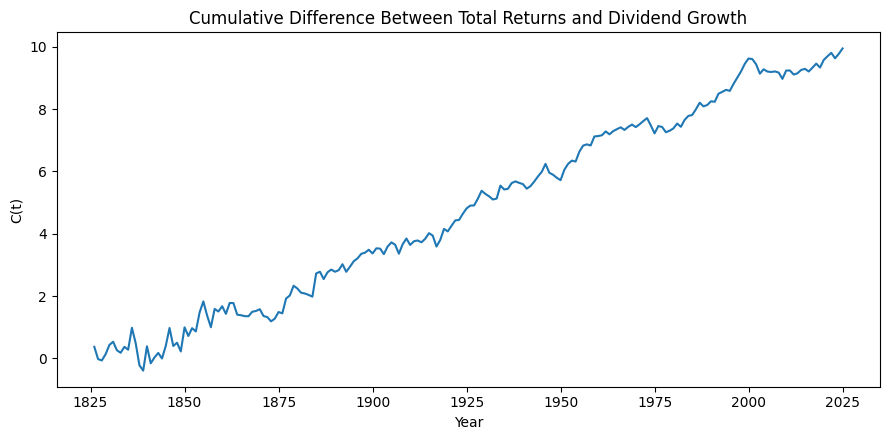

In [7]:
plt.figure(figsize=(9, 4.5))
plt.plot(model_data["Year"], model_data["C"])
plt.xlabel("Year")
plt.ylabel("C(t)")
plt.title("Cumulative Difference Between Total Returns and Dividend Growth")
plt.tight_layout()
plt.show()

## 4. Model estimation

The fitted equation is

$$
X_t=\alpha+\beta t-\gamma C_{t-1}+Z_t.
$$

The equivalent parameters are

$$
b=1-\gamma,\qquad
c=\frac{\beta}{\gamma},\qquad
a=\alpha-bc.
$$

In [8]:
reg = model_data.dropna(subset=["C_lag"]).copy()

Xreg = sm.add_constant(reg[["t", "C_lag"]])
fit = sm.OLS(reg["X"], Xreg).fit()

alpha = fit.params["const"]
beta = fit.params["t"]
gamma = -fit.params["C_lag"]

b = 1 - gamma
c = beta / gamma
a = alpha - b*c

print("Regression sample:", int(reg["Year"].min()), "-", int(reg["Year"].max()))
print("Observations:", len(reg))
print()
print("a =", round(a, 6))
print("b =", round(b, 6))
print("c =", round(c, 6))
print("trend =", round(100*c, 2), "%")

Regression sample: 1827 - 2025
Observations: 199

a = -0.150192
b = 0.766458
c = 0.053898
trend = 5.39 %


## 5. Valuation measure and mean reversion

The detrended valuation measure is

$$
H_t=C_t-ct.
$$

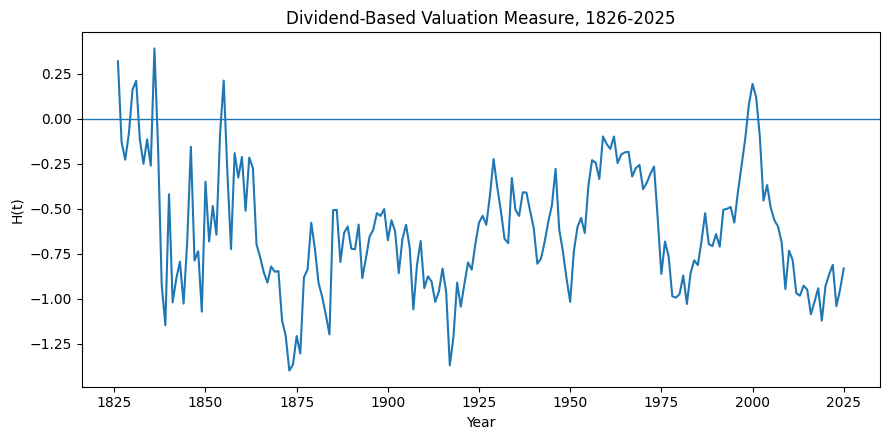

ADF statistic: -3.4997
ADF p-value: 0.008
5% critical value: -2.8772


In [9]:
model_data["H"] = model_data["C"] - c*model_data["t"]

plt.figure(figsize=(9, 4.5))
plt.plot(model_data["Year"], model_data["H"])
plt.axhline(0, linewidth=1)
plt.xlabel("Year")
plt.ylabel("H(t)")
plt.title("Dividend-Based Valuation Measure, 1826-2025")
plt.tight_layout()
plt.show()

adf = adfuller(model_data["H"].dropna(), regression="c", autolag="AIC")
print("ADF statistic:", round(adf[0], 4))
print("ADF p-value:", round(adf[1], 4))
print("5% critical value:", round(adf[4]["5%"], 4))

## 6. Confidence interval for the trend

Since $c=\beta/\gamma$, the interval uses the joint estimated covariance of $\widehat{\beta}$ and $\widehat{\gamma}$. The 95% interval is obtained from the simulated distribution of the ratio.

In [10]:
cov_fit = fit.cov_params()
cov_bg = np.array([
    [cov_fit.loc["t", "t"], -cov_fit.loc["t", "C_lag"]],
    [-cov_fit.loc["C_lag", "t"], cov_fit.loc["C_lag", "C_lag"]]
])

rng = np.random.default_rng(2026)
draws = rng.multivariate_normal([beta, gamma], cov_bg, size=100000)
c_sim = draws[:, 0] / draws[:, 1]
ci_low, ci_high = np.quantile(c_sim, [0.025, 0.975])

print("Estimated trend:", round(100*c, 2), "%")
print("95% CI:", (round(100*ci_low, 2), round(100*ci_high, 2)), "%")

Estimated trend: 5.39 %
95% CI: (np.float64(5.16), np.float64(5.63)) %


## 7. Residual diagnostics

The residual ACF and Ljung-Box tests assess serial dependence in $Z_t$. Ljung-Box tests on $Z_t^2$ check for dependence in the residual variance. Gaussianity is examined with the Q-Q plot, Shapiro-Wilk test, and Jarque-Bera test.

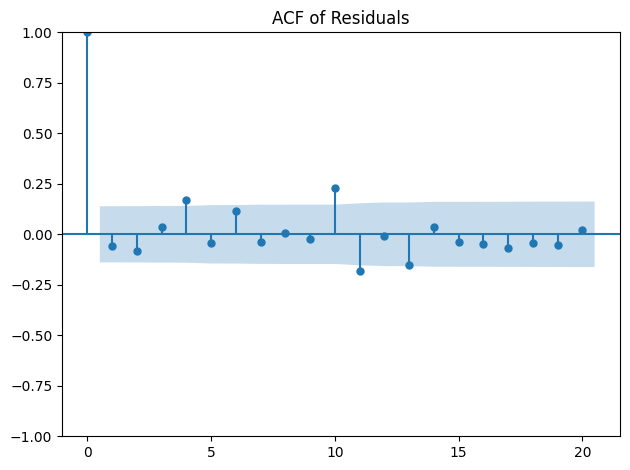

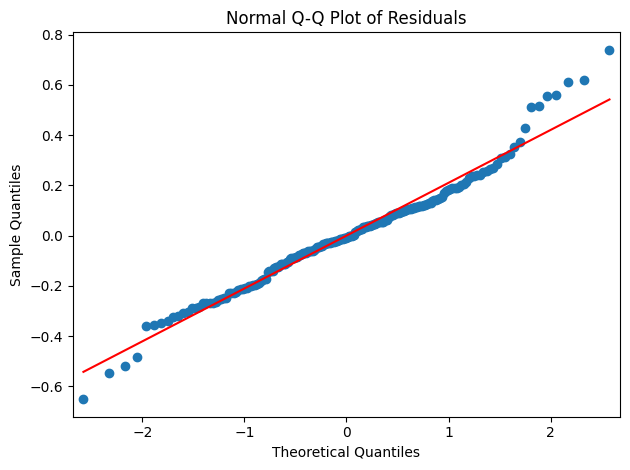

In [11]:
reg["Z"] = fit.resid

plot_acf(reg["Z"], lags=20)
plt.title("ACF of Residuals")
plt.tight_layout()
plt.show()

sm.qqplot(reg["Z"], line="s")
plt.title("Normal Q-Q Plot of Residuals")
plt.tight_layout()
plt.show()

sw = shapiro(reg["Z"])
jb = jarque_bera(reg["Z"])
lb = acorr_ljungbox(reg["Z"], lags=[5, 10], return_df=True)
lb2 = acorr_ljungbox(reg["Z"]**2, lags=[5, 10], return_df=True)

In [12]:
print("Shapiro-Wilk p-value:", round(sw.pvalue, 4))
print("Jarque-Bera p-value:", round(jb.pvalue, 4))
print()
print("Ljung-Box for Z")
print(lb.round(4))
print()
print("Ljung-Box for Z^2")
print(lb2.round(4))

Shapiro-Wilk p-value: 0.0021
Jarque-Bera p-value: 0.0001

Ljung-Box for Z
    lb_stat  lb_pvalue
5    8.8394     0.1156
10  23.0092     0.0107

Ljung-Box for Z^2
     lb_stat  lb_pvalue
5    67.7283        0.0
10  119.0078        0.0


## 8. Summary

In [13]:
print("Combined data span: 1825-2025")
print("Effective regression sample:", int(reg["Year"].min()), "-", int(reg["Year"].max()))
print("b =", round(b, 4))
print("c =", round(100*c, 2), "%")
print("95% CI for c =", (round(100*ci_low, 2), round(100*ci_high, 2)), "%")
print("ADF p-value =", round(adf[1], 4))
print("Shapiro-Wilk p-value =", round(sw.pvalue, 4))
print("Jarque-Bera p-value =", round(jb.pvalue, 4))
print("Ljung-Box p-value, lag 10 =", round(lb.loc[10, "lb_pvalue"], 4))
print("Ljung-Box Z^2 p-value, lag 10 =", round(lb2.loc[10, "lb_pvalue"], 4))

Combined data span: 1825-2025
Effective regression sample: 1827 - 2025
b = 0.7665
c = 5.39 %
95% CI for c = (np.float64(5.16), np.float64(5.63)) %
ADF p-value = 0.008
Shapiro-Wilk p-value = 0.0021
Jarque-Bera p-value = 0.0001
Ljung-Box p-value, lag 10 = 0.0107
Ljung-Box Z^2 p-value, lag 10 = 0.0
